<a href="https://colab.research.google.com/github/SattamAltwaim/StarX/blob/main/experiments/16_build_assembly_shards.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Setup: clone the StarX repo and the pinned TripoSR commit, install this
# notebook's dependencies, mount Drive, and report what machine we are on.
import os
import subprocess
import sys

BRANCH = "main"
TRIPOSR_COMMIT = "107cefdc244c39106fa830359024f6a2f1c78871"
NOTEBOOK_ID = "16"

IN_COLAB = os.path.exists("/content")
if IN_COLAB:
    REPO_DIR = "/content/StarX"
    if not os.path.exists(REPO_DIR):
        subprocess.run(
            ["git", "clone", "--branch", BRANCH,
             "https://github.com/SattamAltwaim/StarX.git", REPO_DIR],
            check=True,
        )
    TRIPOSR_DIR = "/content/TripoSR"
else:
    # off Colab the kernel's cwd is unpredictable (VS Code often starts in
    # $HOME) - walk up from the notebook location and the cwd to find the
    # repo, with ~/StarX as the final fallback
    def _find_repo():
        candidates = [globals().get("__vsc_ipynb_file__"), os.getcwd()]
        for start in candidates:
            if not start:
                continue
            path = os.path.abspath(
                os.path.dirname(start) if os.path.isfile(start) else start
            )
            while path != os.path.dirname(path):
                if os.path.exists(os.path.join(path, "starx", "pins.py")):
                    return path
                path = os.path.dirname(path)
        home_repo = os.path.join(os.path.expanduser("~"), "StarX")
        if os.path.exists(os.path.join(home_repo, "starx", "pins.py")):
            return home_repo
        raise RuntimeError(
            "could not locate the StarX repo - start Jupyter inside it "
            "or clone it to ~/StarX"
        )

    REPO_DIR = _find_repo()
    TRIPOSR_DIR = os.path.join(REPO_DIR, "third_party", "TripoSR")
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

if not os.path.exists(TRIPOSR_DIR):
    subprocess.run(
        ["git", "clone", "https://github.com/VAST-AI-Research/TripoSR.git",
         TRIPOSR_DIR],
        check=True,
    )
subprocess.run(["git", "-C", TRIPOSR_DIR, "checkout", "-q", TRIPOSR_COMMIT], check=True)

from starx import pins

assert pins.TRIPOSR_COMMIT == TRIPOSR_COMMIT, "notebook pin out of sync with starx/pins.py"
# .get, not [NOTEBOOK_ID]: same situation as notebooks 13/14/15 - this pin
# never made it into the upstream starx/pins.py.
if pins.PIP_PINS.get(NOTEBOOK_ID):
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", *pins.PIP_PINS[NOTEBOOK_ID]],
        check=True,
    )
subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q", "trimesh", "pyrender", "py7zr"],
    check=True,
)
# The stock PyOpenGL release has a bug ("TypeError: unhashable type" inside
# OpenGL/contextdata.py) that breaks pyrender's headless EGL/OSMesa paths on
# Colab - this bit notebook 15 the hard way. Fix it before pyrender is ever
# imported, not after something fails.
subprocess.run(
    [sys.executable, "-m", "pip", "uninstall", "-y", "pyopengl", "pyopengl-accelerate"],
    check=True,
)
subprocess.run(
    [sys.executable, "-m", "pip", "install",
     "git+https://github.com/mcfletch/pyopengl.git@227f9c66976d9f5dadf62b9a97e6beaec84831ca"],
    check=True,
)
# OSMesa system library, in case EGL is unavailable/flaky on this runtime and
# the CPU fallback is needed (apt, not pip - pyrender's OSMesa binding needs
# the actual Mesa library present, not just the Python wrapper).
subprocess.run(["apt-get", "-qq", "update"], check=True)
subprocess.run(
    ["apt-get", "-qq", "install", "-y", "libosmesa6-dev", "freeglut3-dev"], check=True
)

from starx import colab as scolab

DRIVE = scolab.mount_drive()
report = scolab.setup_report()

Mounted at /content/drive
        python: 3.12.13
         torch: 2.11.0+cu128
cuda_available: True
           gpu: Tesla T4
       vram_gb: 14.6
  disk_free_gb: 65.6
     cpu_count: 2
      in_colab: True


# 16 - Build the assembly dataset's training shards

The real data build for the assembly dataset, mirroring notebook 03: one
pass over every body produces ground-truth renders, masks, and cameras,
packed into resumable tar shards on Drive in the *exact* format
`starx.shards` / `starx.sketchdata` already read - so `build_sketch_shards`
and `SketchDataset` work against this data unchanged, no new plumbing.

Two deliberate differences from notebook 03:

1. **No native-sketch channel.** Confirmed in notebooks 13/14: the assembly
   dataset's JSON is a B-Rep joint/contact descriptor, not a sketch/timeline
   construction record - there is nothing for `starx.rasterize` to draw.
   Every shard still writes a `{id}.sketch.png` member (the format requires
   it), but it's a flat placeholder, and `meta["has_native_sketch"] = False`
   marks it as such. Nothing downstream reads that member for the
   `train_sketch.py` recipe anyway (`SketchDataset` never touches
   `.sketch.png` - only `.view*.png`, `.cameras.npy`, `.edge*.png`).
2. **No alignment gate.** Notebook 03's gate verifies pyrender's cameras
   agree with TripoSR's own renderer - a property of `starx.render_gt` /
   `starx.cameras` themselves, not of which meshes get rendered through
   them. That was already proven once, for the same unchanged rendering
   code; it doesn't need re-proving per dataset.

The last cell runs `starx.sketchdata.build_sketch_shards` - unchanged,
existing, tested code - against the shards this notebook builds, to derive
the actual per-view Sobel sketches from the GT renders. That supersedes
notebook 15's approach for anything meant to actually train on: notebook 15
was a hand-rolled prototype to prove render+Sobel worked on this mesh
source at all; this is the same idea flowing through the real,
shard-based, DataLoader-compatible pipeline.

Use a GPU runtime. Resumable: re-running after a disconnect picks up where
it stopped, same as notebook 03.

In [2]:
# Configuration - every tunable for this notebook lives here.
import json
import random
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import py7zr
import torch
import trimesh
from tqdm.auto import tqdm

from starx import cameras, checkpoint, render_gt, shards, sketchdata, viz
from starx.config import CAMERA_DISTANCE, FOVY_DEG, SCENE_RADIUS, StarXConfig

SMOKE = False        # True: tiny splits into smoke_train/smoke_test dirs
LIMIT_DESIGNS = 20     # bodies per split when SMOKE is on
OVERWRITE = False      # True: rebuild shards even when their marker exists
SEED = 1337
SPLIT_PREFIX = "smoke_" if SMOKE else ""

ASSEMBLY_DATA_URL = (
    "https://fusion-360-gallery-dataset.s3.us-west-2.amazonaws.com/"
    "assembly/j1.0.0/j1.0.0.7z"
)

cfg = StarXConfig(
    drive_root=str(DRIVE / "StarX")
    if DRIVE is not None
    else os.path.join(REPO_DIR, "data", "StarX"),
    gt_size=256,
    n_views=16,
    elev_range=(-10.0, 45.0),
    shard_size=200,
    seed=SEED,
)
archive_drive_path = Path(cfg.drive_root) / "raw" / "j1.0.0.7z"
error_log = Path(cfg.drive_root) / "assembly_shards" / f"{SPLIT_PREFIX}errors.jsonl"

# Own dirs, parallel to but never overlapping the reconstruction dataset's
# shards/ and sketch_shards/ - starx.config.shard_dir is hardcoded to those.
def assembly_shard_dir(cfg, split):
    return Path(cfg.drive_root) / "assembly_shards" / split


def assembly_sketch_shard_dir(cfg, split):
    return Path(cfg.drive_root) / "assembly_sketch_shards" / split


def assembly_stats_dir(cfg):
    return Path(cfg.drive_root) / "assembly_stats"


# The .sketch.png placeholder every shard writes - see the intro markdown
# for why. Built once; every body's shard entry reuses this exact array.
BLANK_STACK = np.full(
    (cfg.max_sketch_channels, cfg.sketch_size, cfg.sketch_size),
    cfg.bg_value,
    dtype=np.uint8,
)

# fixed by the pretrained checkpoint - printed, never tuned
print(f"camera distance {CAMERA_DISTANCE}   fovy {FOVY_DEG} deg   scene radius {SCENE_RADIUS}")
print(f"views per body: {cfg.n_views}   elevation range: {cfg.elev_range}")
print("archive on Drive lands at:", archive_drive_path)

camera distance 1.9   fovy 40.0 deg   scene radius 0.87
views per body: 16   elevation range: (-10.0, 45.0)
archive on Drive lands at: /content/drive/MyDrive/StarX/raw/j1.0.0.7z


In [3]:
# Get the archive onto fast local disk (and archived on Drive). Same
# download logic as notebooks 13/14/15 - redefined here since it isn't in
# the upstream starx.colab (hardcoded to r1.0.1.zip / zipfile there).
def ensure_assembly_archive_local(url, drive_path, local_dir):
    local_archive = Path(local_dir) / "j1.0.0.7z"
    if local_archive.exists():
        return local_archive
    if drive_path.exists():
        return scolab.copy_with_progress(drive_path, local_archive)
    scolab.download_with_progress(url, local_archive)
    if Path(cfg.drive_root).exists():
        scolab.copy_with_progress(local_archive, drive_path)
    return local_archive


archive_local_dir = "/content" if IN_COLAB else os.path.join(REPO_DIR, "data")
archive_path = ensure_assembly_archive_local(
    ASSEMBLY_DATA_URL, archive_drive_path, archive_local_dir
)
size_gib = archive_path.stat().st_size / 2**30
print(f"archive ready at {archive_path} ({size_gib:.2f} GiB)")

download j1.0.0.7z:   0%|          | 0.00/2.98G [00:00<?, ?B/s]

archive ready at /content/j1.0.0.7z (2.77 GiB)


In [4]:
# Every per-body .obj under j1.0.0/joint/ is its own design, same unit
# notebooks 14/15 use. Then a fresh seeded 80/20 split, since this dataset
# has no notebook-01 equivalent to provide one yet - cached to Drive so
# every later run (and every other notebook) sees the same split.
with py7zr.SevenZipFile(archive_path, mode="r") as _archive:
    names = _archive.getnames()

obj_names = [
    n for n in names if n.startswith("j1.0.0/joint/") and n.endswith(".obj")
]
design_ids = sorted(os.path.splitext(os.path.basename(n))[0] for n in obj_names)
print(f"{len(design_ids)} bodies with a .obj under j1.0.0/joint/")

splits_path = assembly_stats_dir(cfg) / "assembly_splits.json"
if splits_path.exists():
    assembly_splits = json.loads(splits_path.read_text())
    print("loaded cached splits from Drive")
else:
    rng_split = random.Random(SEED)
    shuffled = design_ids[:]
    rng_split.shuffle(shuffled)
    cut = int(0.8 * len(shuffled))
    assembly_splits = {"train": sorted(shuffled[:cut]), "test": sorted(shuffled[cut:])}
    splits_path.parent.mkdir(parents=True, exist_ok=True)
    splits_path.write_text(json.dumps(assembly_splits))
    print("wrote a fresh seeded split to Drive")

train_ids = assembly_splits["train"]
test_ids = assembly_splits["test"]
if SMOKE:
    train_ids = train_ids[:LIMIT_DESIGNS]
    test_ids = test_ids[: max(4, LIMIT_DESIGNS // 4)]
print(f"train bodies: {len(train_ids)}   test bodies: {len(test_ids)}")

23029 bodies with a .obj under j1.0.0/joint/
wrote a fresh seeded split to Drive
train bodies: 18423   test bodies: 4606


renderer backend: egl


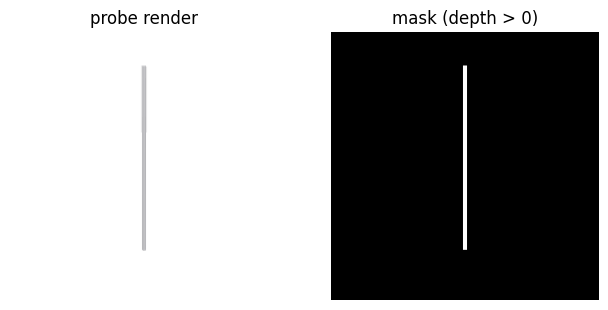

In [5]:
# Start the offscreen renderer and prove it works with one render - same
# class, same call, as notebook 03 uses for the reconstruction dataset.
WORK_DIR = Path("/content/work") if IN_COLAB else Path(REPO_DIR) / "data" / "work"

renderer = render_gt.GTRenderer(cfg.gt_size)
print("renderer backend:", renderer.backend)

SAMPLE_ID = train_ids[0]
sample_member = f"j1.0.0/joint/{SAMPLE_ID}.obj"
with py7zr.SevenZipFile(archive_path, mode="r") as _archive:
    _archive.extract(path=WORK_DIR, targets=[sample_member])

raw_mesh = trimesh.load(WORK_DIR / sample_member, force="mesh")
probe_c2w = cameras.build_spherical_c2w(30.0, 20.0, CAMERA_DISTANCE)
probe_rgb, probe_mask = renderer.render_mesh(
    render_gt.normalize_mesh(raw_mesh)[0], [probe_c2w]
)
fig, axes = plt.subplots(1, 2, figsize=(7.6, 3.8))
axes[0].imshow(probe_rgb[0])
axes[0].set_title("probe render")
axes[1].imshow(probe_mask[0], cmap="gray")
axes[1].set_title("mask (depth > 0)")
for ax in axes:
    ax.axis("off")
plt.show()

decoded keys: ['design_id', 'stack', 'views', 'masks', 'c2ws', 'meta']
views: (16, 256, 256, 3)  masks: (16, 256, 256)  c2ws: (16, 4, 4)


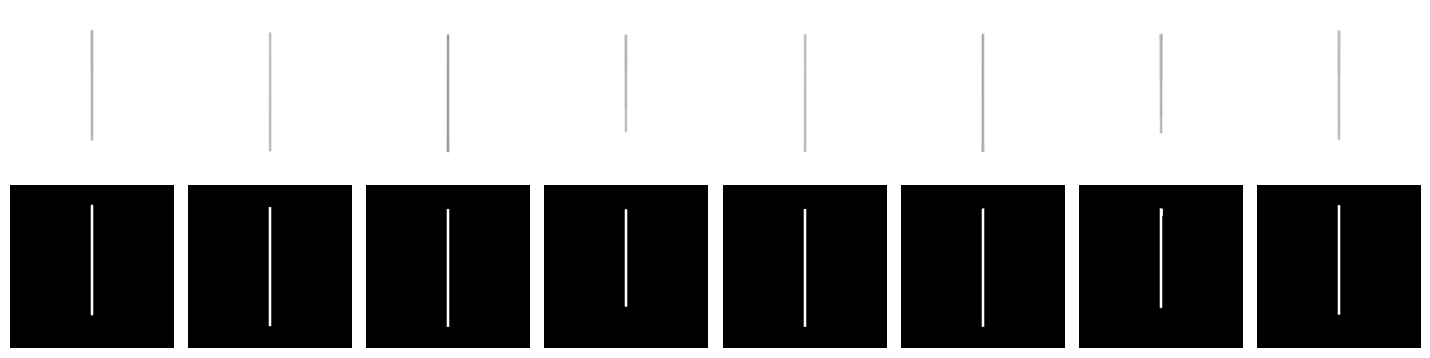

In [6]:
# The per-body worker: obj -> normalized mesh -> posed renders, encoded as
# tar members. Demonstrated on the sample body, then decoded back to prove
# the storage roundtrip - same shape as notebook 03's process_design demo.
def process_body(design_id, split):
    obj_path = WORK_DIR / f"j1.0.0/joint/{design_id}.obj"
    mesh = trimesh.load(obj_path, force="mesh")
    norm_mesh, center, scale = render_gt.normalize_mesh(mesh)
    c2ws_d, angles_d = cameras.sample_design_views(
        design_id, cfg.n_views, cfg.elev_range, seed=cfg.seed
    )
    rgbs_d, masks_d = renderer.render_mesh(norm_mesh, c2ws_d)
    meta_d = {
        "design_id": design_id,
        "split": split,
        "has_native_sketch": False,
        "mesh_center_cm": [float(x) for x in center],
        "mesh_scale": float(scale),
        "view_angles": [[float(a), float(e)] for a, e in angles_d],
    }
    return shards.encode_sample(design_id, BLANK_STACK, rgbs_d, masks_d, c2ws_d, meta_d)


demo_members = process_body(SAMPLE_ID, "demo")
decoded = shards.decode_sample(dict(demo_members))
print("decoded keys:", list(decoded))
print("views:", decoded["views"].shape, " masks:", decoded["masks"].shape,
      " c2ws:", decoded["c2ws"].shape)
fig = viz.show_view_grid(list(decoded["views"][:8]), list(decoded["masks"][:8]))
plt.show()

smoke shards:   0%|          | 0/1 [00:00<?, ?it/s]

shard 0:   0%|          | 0/20 [00:00<?, ?it/s]

smoke: 1/1 shards done


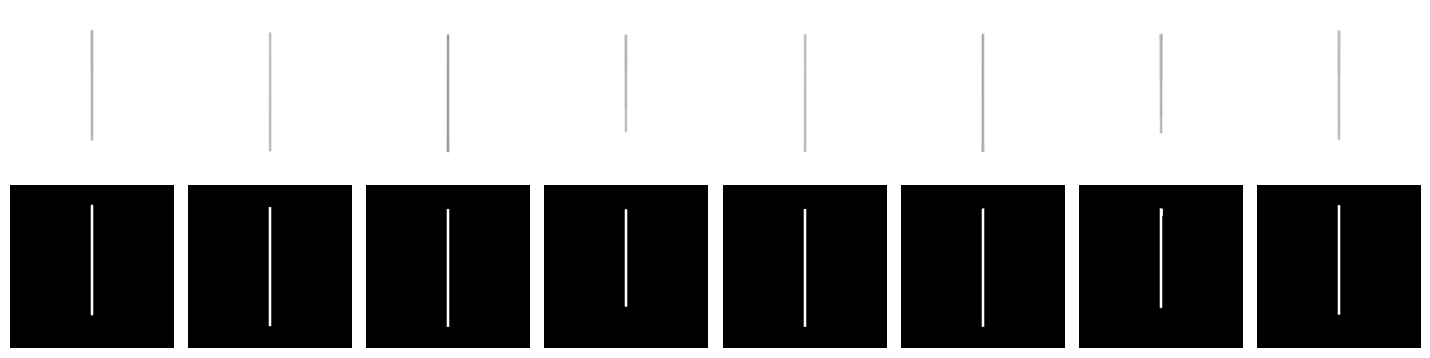

100218_83ec552f_0000_1 [[305.9139404296875, 23.535701751708984], [48.256492614746094, -3.233243703842163]]


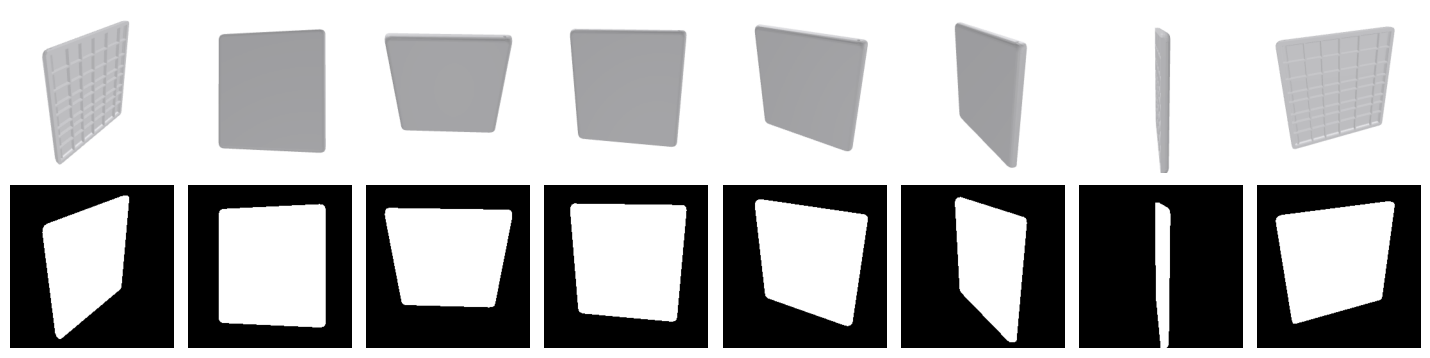

100218_83ec552f_0000_2 [[310.36865234375, 32.35675048828125], [190.0151824951172, -0.5020295977592468]]


In [7]:
# The shard builder, smoke-tested on a handful of bodies before committing
# to the full run. Extracts a whole shard's-worth of meshes from the
# archive in one pass (matching notebook 03's "open the zip once per
# chunk" efficiency), not one archive-open per body.
def build_split(split, ids):
    out_dir = assembly_shard_dir(cfg, split)
    chunks = [ids[i : i + cfg.shard_size] for i in range(0, len(ids), cfg.shard_size)]
    for index, chunk in enumerate(tqdm(chunks, desc=f"{split} shards")):
        final_tar = out_dir / shards.shard_name(index)
        if shards.marker_path(final_tar).exists() and not OVERWRITE:
            continue
        chunk_members = [f"j1.0.0/joint/{d}.obj" for d in chunk]
        with py7zr.SevenZipFile(archive_path, mode="r") as _archive:
            _archive.extract(path=WORK_DIR, targets=chunk_members)

        writer = shards.ShardWriter(out_dir, index)
        for design_id in tqdm(chunk, desc=f"shard {index}", leave=False):
            try:
                writer.add(process_body(design_id, split))
            except Exception as error:
                checkpoint.append_log(
                    error_log,
                    {"design_id": design_id, "split": split, "error": repr(error)},
                )
            finally:
                obj_path = WORK_DIR / f"j1.0.0/joint/{design_id}.obj"
                if obj_path.exists():
                    obj_path.unlink()
        writer.close()
    done = shards.list_done_shards(out_dir)
    print(f"{split}: {len(done)}/{len(chunks)} shards done")


build_split("smoke", train_ids[:20])
smoke_tars = shards.list_done_shards(assembly_shard_dir(cfg, "smoke"))
for i, sample in enumerate(shards.iter_shard(smoke_tars[0])):
    if i >= 2:
        break
    fig = viz.show_view_grid(list(sample["views"][:8]), list(sample["masks"][:8]))
    plt.show()
    print(sample["design_id"], sample["meta"]["view_angles"][:2])

In [8]:
# Build the train split. This is the long cell (hours for the full set):
# it survives disconnects - finished shards are skipped on re-run, so just
# run the notebook again to resume where it stopped.
build_split(f"{SPLIT_PREFIX}train", train_ids)

train shards:   0%|          | 0/93 [00:00<?, ?it/s]

shard 0:   0%|          | 0/200 [00:00<?, ?it/s]

shard 1:   0%|          | 0/200 [00:00<?, ?it/s]

shard 2:   0%|          | 0/200 [00:00<?, ?it/s]

shard 3:   0%|          | 0/200 [00:00<?, ?it/s]

...

shard 89:   0%|          | 0/200 [00:00<?, ?it/s]

shard 90:   0%|          | 0/200 [00:00<?, ?it/s]

shard 91:   0%|          | 0/200 [00:00<?, ?it/s]

shard 92:   0%|          | 0/23 [00:00<?, ?it/s]

train: 93/93 shards done


In [9]:
# Build the test split the same way.
build_split(f"{SPLIT_PREFIX}test", test_ids)

test shards:   0%|          | 0/24 [00:00<?, ?it/s]

shard 0:   0%|          | 0/200 [00:00<?, ?it/s]

shard 1:   0%|          | 0/200 [00:00<?, ?it/s]

shard 2:   0%|          | 0/200 [00:00<?, ?it/s]

shard 3:   0%|          | 0/200 [00:00<?, ?it/s]

...

shard 20:   0%|          | 0/200 [00:00<?, ?it/s]

shard 21:   0%|          | 0/200 [00:00<?, ?it/s]

shard 22:   0%|          | 0/200 [00:00<?, ?it/s]

shard 23:   0%|          | 0/6 [00:00<?, ?it/s]

test: 24/24 shards done


In [10]:
# Build report: shard completion, sizes on Drive, and what failed.
report_rows = []
for split, ids in ((f"{SPLIT_PREFIX}train", train_ids), (f"{SPLIT_PREFIX}test", test_ids)):
    done = shards.list_done_shards(assembly_shard_dir(cfg, split))
    expected = int(np.ceil(len(ids) / cfg.shard_size))
    total_gb = sum(p.stat().st_size for p in done) / 2**30
    report_rows.append(
        {"split": split, "shards done": len(done), "expected": expected,
         "size GiB": round(total_gb, 2)}
    )
display(pd.DataFrame(report_rows))

errors_df = checkpoint.read_log(error_log)
if errors_df.empty:
    print("no per-body failures logged")
else:
    print(f"{len(errors_df)} bodies failed:")
    display(errors_df["error"].value_counts().head(10))

,split,shards done,expected,size GiB
0,train,93,93,1.89
1,test,24,24,0.47


no per-body failures logged


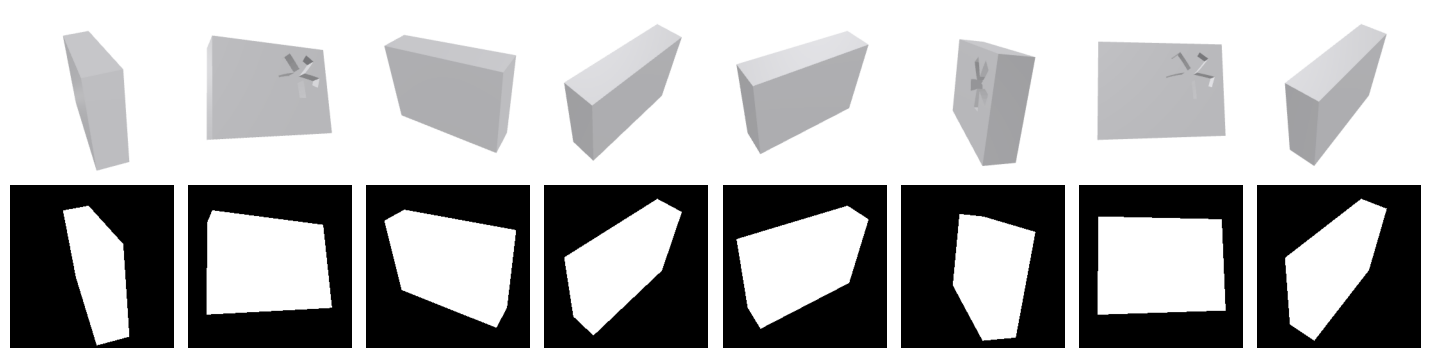

54073_7d8cdd04_0010_2  has_native_sketch: False


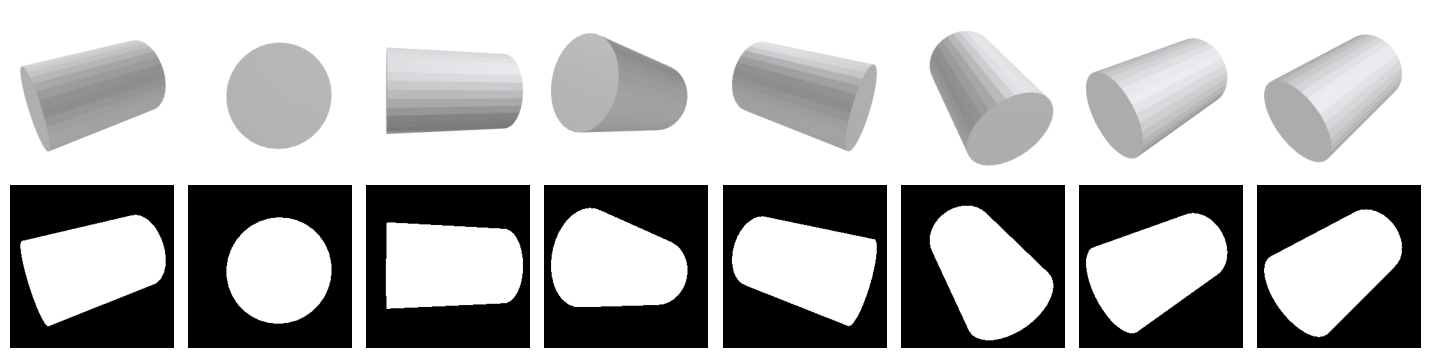

54172_eb723054_0022_1  has_native_sketch: False


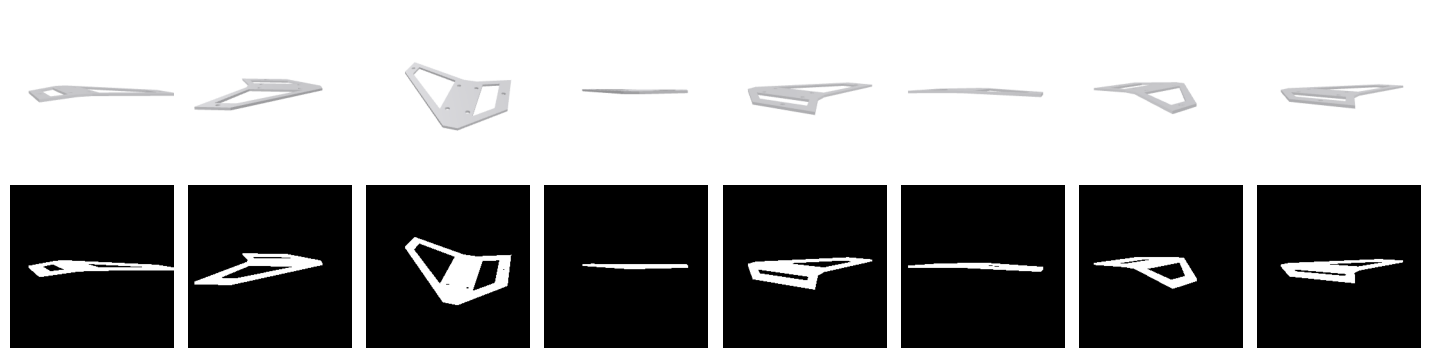

49886_dd68dccb_0039_2  has_native_sketch: False


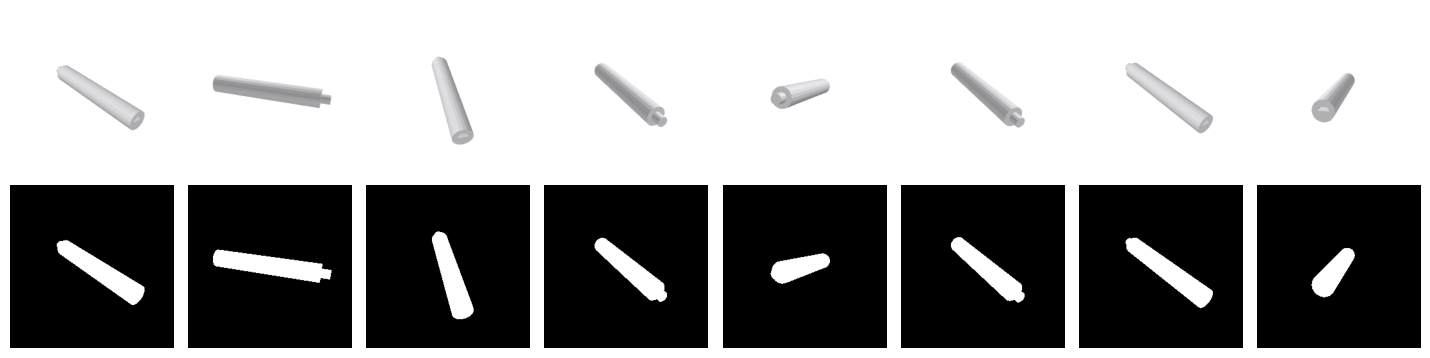

50001_e86a6698_0009_2  has_native_sketch: False


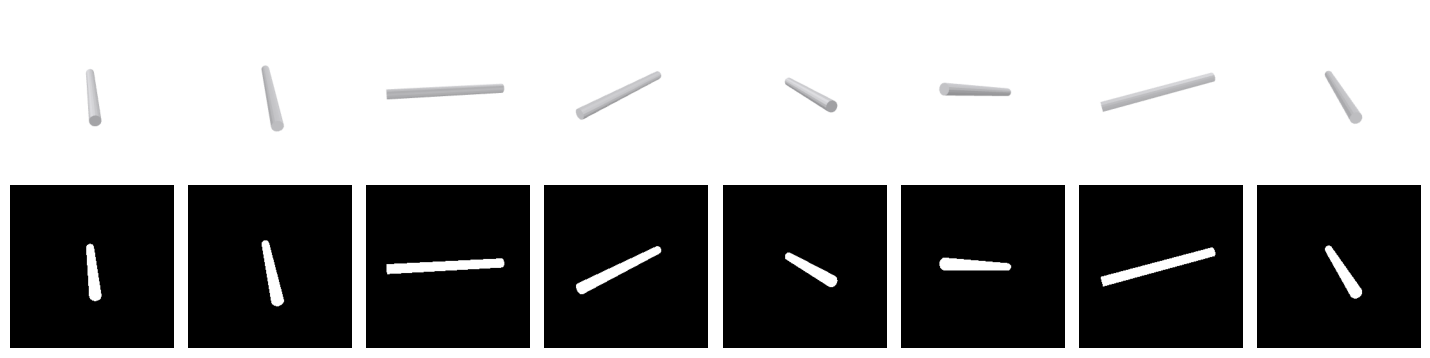

83451_2164a15b_0003_1  has_native_sketch: False


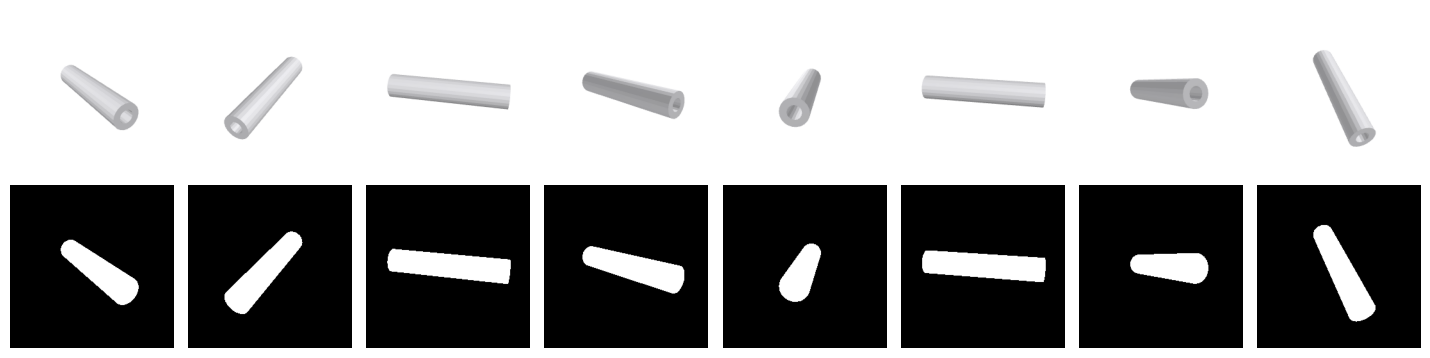

88783_81cdf9fe_0010_1  has_native_sketch: False


In [11]:
# Random quality check: pull a few finished samples straight off Drive and
# eyeball the renders. The sketch strip is the flat placeholder by design -
# not a bug, see the intro markdown.
rng_qa = random.Random(SEED)
done_train = shards.list_done_shards(assembly_shard_dir(cfg, f"{SPLIT_PREFIX}train"))
qa_samples = []
for tar in rng_qa.sample(done_train, min(3, len(done_train))):
    shard_samples = list(shards.iter_shard(tar))
    qa_samples.extend(rng_qa.sample(shard_samples, min(2, len(shard_samples))))

for sample in qa_samples[:6]:
    fig = viz.show_view_grid(list(sample["views"][:8]), list(sample["masks"][:8]))
    plt.show()
    print(sample["design_id"], " has_native_sketch:",
          sample["meta"]["has_native_sketch"])

In [ ]:
# Derive the actual per-view synthetic sketches from these GT renders,
# using the existing, unchanged starx.sketchdata pipeline - the same code
# path notebook 10 uses for the reconstruction dataset. This supersedes
# notebook 15's standalone prototype: real shards in, real sketch shards
# out, in the exact format SketchDataset already reads.
sketch_stats = {}
for split in (f"{SPLIT_PREFIX}train", f"{SPLIT_PREFIX}test"):
    stats = sketchdata.build_sketch_shards(
        assembly_shard_dir(cfg, split),
        assembly_sketch_shard_dir(cfg, split),
        cfg,
        device="cuda" if torch.cuda.is_available() else "cpu",
        progress=tqdm,
    )
    sketch_stats[split] = stats
    print(split, stats)

  0%|          | 0/93 [00:00<?, ?it/s]

train {'shards_built': 93, 'shards_skipped': 0, 'designs': 18423, 'sketches': 294768}


  0%|          | 0/24 [00:00<?, ?it/s]

## Takeaways

- The assembly dataset now has real training shards on Drive at
  `assembly_shards/<split>/` (renders, masks, cameras, metadata) and
  `assembly_sketch_shards/<split>/` (the derived per-view Sobel sketches) -
  the exact format `starx.sketchdata.SketchDataset` already reads. No new
  Dataset class needed; point `SketchDataset(cache_dir=..., cfg=cfg)` at the
  extracted cache the same way `scripts/train_sketch.py` already does for
  the reconstruction dataset.
- `{id}.sketch.png` in every shard is a flat placeholder
  (`meta["has_native_sketch"] = False`) - confirmed real, not a gap to fill:
  this dataset has no native sketch/timeline data to put there.
- Notebook 15 is now superseded for anything meant to actually train on -
  it was the prototype that proved render + Sobel worked on this mesh
  source; this notebook is the real, resumable, DataLoader-compatible build.
- Not addressed here: combining this with the reconstruction dataset for a
  single training run (mixing two shard sets, or two separate DataLoaders),
  and the SSIM3D loss integration into `starx.train`. Both still open.

Next: get these shards onto Ibex (notebook 08's rclone pull, pointed at
`assembly_shards/` and `assembly_sketch_shards/` in addition to what it
already pulls), then the SSIM3D loss wiring, then the continued-fine-tune
training script.